# MIMIC-CXR Preprocessing Pipeline

**What this notebook does:**
- Processes folders `p10` through `p19` one by one
- Filters **frontal views only** (PA and AP)
- Resizes all images to **256×256** grayscale PNG
- Extracts CheXpert 14 binary labels
- Saves a clean `manifest.csv` with image paths + labels

**Expected time:** ~45-90 min depending on Drive speed

## Step 0 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


## Step 1 — Configuration

Edit `DRIVE_BASE` if your folder path is different.

In [ ]:
import os
import gc
import time
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from pathlib import Path


DRIVE_BASE = '/content/drive/MyDrive/cloudBuc'

# Input paths
IMAGES_DIR    = f'{DRIVE_BASE}/files'                               # p10..p19 live here
METADATA_CSV  = f'{DRIVE_BASE}/mimic-cxr-2.0.0-metadata.csv.gz'    # view info
CHEXPERT_CSV  = f'{DRIVE_BASE}/mimic-cxr-2.0.0-chexpert.csv.gz'    # 14 labels

# Output paths
OUTPUT_DIR    = f'{DRIVE_BASE}/preprocessed_256'
OUTPUT_IMAGES = f'{OUTPUT_DIR}/images'

# Settings
TARGET_SIZE   = (256, 256)
FRONTAL_VIEWS = ['PA', 'AP']
PATIENT_FOLDERS = [f'p{i}' for i in range(10, 20)]  # p10 to p19

# CheXpert 14 labels
CHEXPERT_LABELS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]

print(f'Base:    {DRIVE_BASE}')
print(f'Images:  {IMAGES_DIR}')
print(f'Output:  {OUTPUT_DIR}')
print(f'Folders: {PATIENT_FOLDERS}')

Base:    /content/drive/MyDrive/cloudBuc
Images:  /content/drive/MyDrive/cloudBuc/files
Output:  /content/drive/MyDrive/cloudBuc/preprocessed_256
Folders: ['p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16', 'p17', 'p18', 'p19']


## Step 2 — Verify Files Exist

In [ ]:
print('Checking files...\n')

checks = {
    'Metadata CSV':  METADATA_CSV,
    'CheXpert CSV':  CHEXPERT_CSV,
    'Images folder': IMAGES_DIR,
}

for name, path in checks.items():
    ok = os.path.exists(path)
    print(f"  {'OK' if ok else 'MISSING':>7}  {name} → {path}")

print('\nPatient folders:')
for pf in PATIENT_FOLDERS:
    fp = os.path.join(IMAGES_DIR, pf)
    exists = os.path.isdir(fp)
    if exists:
        n_sub = len(os.listdir(fp))
        print(f'  OK  {pf}/ — {n_sub} patient subdirectories')
    else:
        print(f'  MISSING  {pf}/')

Checking files...

       OK  Metadata CSV → /content/drive/MyDrive/cloudBuc/mimic-cxr-2.0.0-metadata.csv.gz
       OK  CheXpert CSV → /content/drive/MyDrive/cloudBuc/mimic-cxr-2.0.0-chexpert.csv.gz
       OK  Images folder → /content/drive/MyDrive/cloudBuc/files

Patient folders:
  OK  p10/ — 6396 patient subdirectories
  OK  p11/ — 6571 patient subdirectories
  OK  p12/ — 6526 patient subdirectories
  OK  p13/ — 6548 patient subdirectories
  OK  p14/ — 6506 patient subdirectories
  OK  p15/ — 6592 patient subdirectories
  OK  p16/ — 6476 patient subdirectories
  OK  p17/ — 6642 patient subdirectories
  OK  p18/ — 6543 patient subdirectories
  OK  p19/ — 6579 patient subdirectories


## Step 3 — Load Metadata & Filter Frontal Views

In [ ]:
print('Loading metadata...')
meta_df = pd.read_csv(METADATA_CSV)
print(f'  Total rows: {len(meta_df):,}')
print(f'  Columns: {list(meta_df.columns)}')
print(f'\nView distribution:')
print(meta_df['ViewPosition'].value_counts())

Loading metadata...
  Total rows: 377,110
  Columns: ['dicom_id', 'subject_id', 'study_id', 'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns', 'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning', 'ViewCodeSequence_CodeMeaning', 'PatientOrientationCodeSequence_CodeMeaning']

View distribution:
ViewPosition
AP                147173
PA                 96161
LATERAL            82853
LL                 35133
PA LLD                 4
LAO                    3
RAO                    3
AP AXIAL               2
AP LLD                 2
XTABLE LATERAL         2
AP RLD                 2
SWIMMERS               1
PA RLD                 1
LPO                    1
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Filter frontal views only (PA + AP)
frontal_df = meta_df[meta_df['ViewPosition'].isin(FRONTAL_VIEWS)].copy()
print(f'Frontal views (PA + AP): {len(frontal_df):,} images')
print(f'  PA: {(frontal_df["ViewPosition"] == "PA").sum():,}')
print(f'  AP: {(frontal_df["ViewPosition"] == "AP").sum():,}')
print(f'Dropped lateral/other: {len(meta_df) - len(frontal_df):,}')

Frontal views (PA + AP): 243,334 images
  PA: 96,161
  AP: 147,173
Dropped lateral/other: 133,776


## Step 4 — Load CheXpert Labels & Merge

In [ ]:
print('Loading CheXpert labels...')
chex_df = pd.read_csv(CHEXPERT_CSV)
print(f'  Rows: {len(chex_df):,}')

# Merge on subject_id + study_id
merged_df = frontal_df.merge(
    chex_df, on=['subject_id', 'study_id'], how='inner'
)
print(f'  After merge: {len(merged_df):,} frontal images with labels')

# Convert labels to binary:
#   1.0  → 1 (positive)
#   0.0  → 0 (negative)
#  -1.0  → 0 (uncertain → treat as negative)
#   NaN  → 0 (not mentioned → treat as negative)
for col in CHEXPERT_LABELS:
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].fillna(0).apply(lambda x: 1 if x == 1.0 else 0).astype(int)

print(f'\nLabel distribution (positive counts):')
for col in CHEXPERT_LABELS:
    if col in merged_df.columns:
        n = merged_df[col].sum()
        pct = n / len(merged_df) * 100
        print(f'  {col:30s}  {n:>7,}  ({pct:.1f}%)')

Loading CheXpert labels...
  Rows: 227,827
  After merge: 243,324 frontal images with labels

Label distribution (positive counts):
  No Finding                       81,117  (33.3%)
  Enlarged Cardiomediastinum        7,657  (3.1%)
  Cardiomegaly                     47,673  (19.6%)
  Lung Opacity                     54,769  (22.5%)
  Lung Lesion                       6,632  (2.7%)
  Edema                            29,331  (12.1%)
  Consolidation                    11,525  (4.7%)
  Pneumonia                        17,222  (7.1%)
  Atelectasis                      48,790  (20.1%)
  Pneumothorax                     11,235  (4.6%)
  Pleural Effusion                 57,721  (23.7%)
  Pleural Other                     2,083  (0.9%)
  Fracture                          4,781  (2.0%)
  Support Devices                  73,294  (30.1%)


## Step 5 — Build Image Paths

MIMIC-CXR file structure:  
`files/p{XX}/p{subject_id}/s{study_id}/{dicom_id}.jpg`

In [ ]:
def build_image_path(row):
    """Construct full path to source JPG from metadata row."""
    sid = str(row['subject_id'])
    prefix = f'p{sid[:2]}'          # p10, p11, ... p19
    study = f's{row["study_id"]}'
    dicom = row['dicom_id']
    return os.path.join(IMAGES_DIR, prefix, f'p{sid}', study, f'{dicom}.jpg')

merged_df['source_path'] = merged_df.apply(build_image_path, axis=1)

# Verify a few paths exist
sample = merged_df['source_path'].sample(10, random_state=42)
found = sum(1 for p in sample if os.path.exists(p))
print(f'Path check: {found}/10 sample images found on disk')
print(f'Example: {sample.iloc[0]}')

Path check: 10/10 sample images found on disk
Example: /content/drive/MyDrive/cloudBuc/files/p19/p19635953/s53383543/29d50a3f-d63c1dff-5181a726-67c1f7d3-73271853.jpg


In [ ]:
# Tag each row with its patient folder (p10..p19)
merged_df['patient_folder'] = merged_df['subject_id'].astype(str).str[:2].apply(lambda x: f'p{x}')

print('Images per folder:')
folder_counts = merged_df['patient_folder'].value_counts().sort_index()
for folder, count in folder_counts.items():
    print(f'  {folder}: {count:,}')
print(f'\n  Total: {folder_counts.sum():,}')

Images per folder:
  p10: 23,611
  p11: 25,037
  p12: 23,970
  p13: 24,575
  p14: 24,059
  p15: 25,282
  p16: 23,702
  p17: 24,168
  p18: 24,604
  p19: 24,316

  Total: 243,324


## Step 6 — Resize & Save (Folder by Folder)

Processes each `p10`..`p19` folder sequentially.  
Progress is saved after each folder — safe to interrupt and resume.

In [ ]:
# PATIENT_FOLDERS = ['p19']

In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import tarfile
import time

OUTPUT_DIR      = '/content/drive/MyDrive/cloudBuc/output'
OUTPUT_IMAGES   = '/content/drive/MyDrive/cloudBuc/images'  # folder containing original images
IMAGES_PER_CLASS_DEFAULT = 2000
IMAGES_PLEURAL_OTHER    = 2000
TAR_OUTPUT       = os.path.join(OUTPUT_DIR, 'mimic_cxr_sampled.tar.gz')
SAMPLED_IMAGES   = os.path.join(OUTPUT_DIR, 'sampled_images_256_f')
os.makedirs(SAMPLED_IMAGES, exist_ok=True)


selected_rows = []

for label in CHEXPERT_LABELS:
    if label not in merged_df.columns:
        continue

    n_per_class = IMAGES_PER_CLASS_DEFAULT
    if label == "Pleural Other":
        n_per_class = IMAGES_PLEURAL_OTHER

    positives = merged_df[merged_df[label] == 1]
    n_avail   = len(positives)
    n_sample  = min(n_per_class, n_avail)
    sampled   = positives.sample(n=n_sample, random_state=42)
    selected_rows.append(sampled)
    print(f'{label:30s}  available={n_avail:>6,}  sampled={n_sample:>6,}')

# Deduplicate — a single image may cover multiple labels
sampled_df = pd.concat(selected_rows).drop_duplicates(subset='source_path')
print(f'\nUnique images selected: {len(sampled_df):,}')

missing_src = 0
for _, row in tqdm(sampled_df.iterrows(), total=len(sampled_df), unit='img'):
    src = os.path.join(OUTPUT_IMAGES, row['source_path'])
    dst = os.path.join(SAMPLED_IMAGES, os.path.basename(row['source_path']))

    if os.path.exists(dst):            # already staged
        continue

    if not os.path.exists(src):
        missing_src += 1
        continue

    img = Image.open(src).convert('L')
    if img.size != (256, 256):
        img = img.resize((256, 256), Image.LANCZOS)
    img.save(dst, 'PNG')

print(f'Staged images: {len(sampled_df) - missing_src:,} | missing source: {missing_src}')

sampled_csv_path = os.path.join(SAMPLED_IMAGES, 'labels_sampled.csv')
sampled_df.to_csv(sampled_csv_path, index=False)
print(f'Saved labels_sampled.csv ({len(sampled_df):,} rows)')

print(f'\nPacking into {TAR_OUTPUT} ...')
tar_start = time.time()

with tarfile.open(TAR_OUTPUT, 'w:gz') as tar:
    tar.add(SAMPLED_IMAGES, arcname='mimic_cxr_sampled')

tar_elapsed = time.time() - tar_start
tar_size_gb = os.path.getsize(TAR_OUTPUT) / 1e9
print(f'Done in {tar_elapsed:.0f}s — tar size: {tar_size_gb:.2f} GB')
print(f'TAR file → {TAR_OUTPUT}')
print('Contents:')
print('  mimic_cxr_sampled/')
print('  ├── labels_sampled.csv')
print('  └── <image_filename>.png  (256x256 grayscale PNGs)')

No Finding                      available=81,117  sampled= 2,000
Enlarged Cardiomediastinum      available= 7,657  sampled= 2,000
Cardiomegaly                    available=47,673  sampled= 2,000
Lung Opacity                    available=54,769  sampled= 2,000
Lung Lesion                     available= 6,632  sampled= 2,000
Edema                           available=29,331  sampled= 2,000
Consolidation                   available=11,525  sampled= 2,000
Pneumonia                       available=17,222  sampled= 2,000
Atelectasis                     available=48,790  sampled= 2,000
Pneumothorax                    available=11,235  sampled= 2,000
Pleural Effusion                available=57,721  sampled= 2,000
Pleural Other                   available= 2,083  sampled= 2,000
Fracture                        available= 4,781  sampled= 2,000
Support Devices                 available=73,294  sampled= 2,000

Unique images selected: 26,224


 15%|█▌        | 4021/26224 [40:57<3:46:08,  1.64img/s]


KeyboardInterrupt: 

In [ ]:
print(merged_df.columns)

Index(['dicom_id', 'subject_id', 'study_id',
       'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns',
       'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning',
       'ViewCodeSequence_CodeMeaning',
       'PatientOrientationCodeSequence_CodeMeaning', 'Atelectasis',
       'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum',
       'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding',
       'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax',
       'Support Devices', 'source_path', 'patient_folder'],
      dtype='object')


In [ ]:

os.makedirs(OUTPUT_IMAGES, exist_ok=True)

# Track progress
progress_file = os.path.join(OUTPUT_DIR, '_progress.txt')
completed_folders = set()
if os.path.exists(progress_file):
    with open(progress_file) as f:
        completed_folders = set(f.read().strip().split('\n'))
    print(f'Resuming — already done: {completed_folders}')


def resize_and_save(src_path, dst_path, size=(256, 256)):
    """Load JPG, convert to grayscale, resize to 256x256, save as PNG."""
    try:
        img = Image.open(src_path)
        img = img.convert('L')               # grayscale
        img = img.resize(size, Image.LANCZOS) # high-quality resize
        img.save(dst_path, 'PNG')
        return True
    except Exception as e:
        return False


# Process folder by folder
all_results = []
total_start = time.time()

for folder in PATIENT_FOLDERS:
    if folder in completed_folders:
        print(f'\n[{folder}] Already processed — skipping')
        # Load previous results for this folder
        prev_csv = os.path.join(OUTPUT_DIR, f'_done_{folder}.csv')
        if os.path.exists(prev_csv):
            all_results.append(pd.read_csv(prev_csv))
        continue

    folder_df = merged_df[merged_df['patient_folder'] == folder].copy()
    if len(folder_df) == 0:
        print(f'\n[{folder}] No frontal images — skipping')
        continue

    print(f'\n{"═" * 55}')
    print(f'  Processing {folder}: {len(folder_df):,} frontal images')
    print(f'{"═" * 55}')

    folder_start = time.time()
    success = 0
    failed = 0
    skipped = 0
    out_filenames = []

    for idx, row in tqdm(folder_df.iterrows(), total=len(folder_df),
                         desc=f'{folder}', unit='img'):
        src = row['source_path']
        dicom_id = row['dicom_id']
        out_name = f'{dicom_id}.png'
        dst = os.path.join(OUTPUT_IMAGES, out_name)

        # Skip if already exists
        if os.path.exists(dst):
            out_filenames.append(out_name)
            skipped += 1
            continue

        if not os.path.exists(src):
            out_filenames.append(None)
            failed += 1
            continue

        ok = resize_and_save(src, dst, TARGET_SIZE)
        if ok:
            out_filenames.append(out_name)
            success += 1
        else:
            out_filenames.append(None)
            failed += 1

    folder_df['image_filename'] = out_filenames
    folder_df = folder_df[folder_df['image_filename'].notna()].copy()

    elapsed = time.time() - folder_start
    print(f'  Done: {success:,} new + {skipped:,} existing, '
          f'{failed:,} failed — {elapsed:.0f}s')

    # Save per-folder checkpoint
    folder_df.to_csv(os.path.join(OUTPUT_DIR, f'_done_{folder}.csv'), index=False)
    all_results.append(folder_df)

    # Mark folder complete
    with open(progress_file, 'a') as f:
        f.write(f'{folder}\n')
    completed_folders.add(folder)

    gc.collect()

total_elapsed = time.time() - total_start
print(f'\nAll folders processed in {total_elapsed/60:.1f} minutes')

Resuming — already done: {'p13', 'p14', 'p10', 'p17', 'p18', 'p15', 'p16', 'p19', 'p12', 'p11'}

[p10] Already processed — skipping

[p11] Already processed — skipping

[p12] Already processed — skipping

[p13] Already processed — skipping

[p14] Already processed — skipping

[p15] Already processed — skipping

[p16] Already processed — skipping

[p17] Already processed — skipping

[p18] Already processed — skipping

[p19] Already processed — skipping

All folders processed in 0.1 minutes


## Step 7 — Build Final Manifest

In [ ]:
# Combine all folder results
final_df = pd.concat(all_results, ignore_index=True)
print(f'Total processed images: {len(final_df):,}')

# Keep only necessary columns
keep_cols = [
    'dicom_id', 'subject_id', 'study_id', 'ViewPosition',
    'image_filename', 'patient_folder',
] + [c for c in CHEXPERT_LABELS if c in final_df.columns]

manifest_df = final_df[keep_cols].copy()

# Verify image files actually exist on disk
manifest_df['exists'] = manifest_df['image_filename'].apply(
    lambda f: os.path.exists(os.path.join(OUTPUT_IMAGES, f))
)
missing = (~manifest_df['exists']).sum()
if missing > 0:
    print(f'Warning: {missing} images in manifest but not on disk — removing')
    manifest_df = manifest_df[manifest_df['exists']].copy()
manifest_df = manifest_df.drop(columns=['exists'])

# Save
manifest_path = os.path.join(OUTPUT_DIR, 'manifest.csv')
manifest_df.to_csv(manifest_path, index=False)
print(f'Manifest saved: {manifest_path}')
print(f'Final dataset size: {len(manifest_df):,} images')

Total processed images: 243,323
Manifest saved: /content/drive/MyDrive/cloudBuc/preprocessed_256/manifest.csv
Final dataset size: 243,323 images


## Step 8 — Dataset Summary

In [ ]:
print(f'{"═" * 55}')
print(f'  DATASET SUMMARY')
print(f'{"═" * 55}')
print(f'  Total images:  {len(manifest_df):,}')
print(f'  Image size:    {TARGET_SIZE[0]}x{TARGET_SIZE[1]} grayscale PNG')
print(f'  View types:    {manifest_df["ViewPosition"].value_counts().to_dict()}')
print(f'\n  Images per folder:')
for folder, count in manifest_df['patient_folder'].value_counts().sort_index().items():
    print(f'    {folder}: {count:>7,}')

print(f'\n  Label distribution (positives):')
for col in CHEXPERT_LABELS:
    if col in manifest_df.columns:
        n = manifest_df[col].sum()
        pct = n / len(manifest_df) * 100
        bar = '#' * int(pct / 2)
        print(f'    {col:30s}  {n:>7,}  ({pct:5.1f}%)  {bar}')

# Disk usage
total_bytes = sum(
    os.path.getsize(os.path.join(OUTPUT_IMAGES, f))
    for f in os.listdir(OUTPUT_IMAGES)
    if f.endswith('.png')
)
print(f'\n  Disk usage: {total_bytes / 1e9:.2f} GB')
print(f'{"═" * 55}')

═══════════════════════════════════════════════════════
  DATASET SUMMARY
═══════════════════════════════════════════════════════
  Total images:  243,323
  Image size:    256x256 grayscale PNG
  View types:    {'AP': 147168, 'PA': 96155}

  Images per folder:
    p10:  23,611
    p11:  25,037
    p12:  23,970
    p13:  24,575
    p14:  24,059
    p15:  25,282
    p16:  23,702
    p17:  24,168
    p18:  24,604
    p19:  24,315

  Label distribution (positives):
    No Finding                       81,117  ( 33.3%)  ################
    Enlarged Cardiomediastinum        7,657  (  3.1%)  #
    Cardiomegaly                     47,673  ( 19.6%)  #########
    Lung Opacity                     54,769  ( 22.5%)  ###########
    Lung Lesion                       6,632  (  2.7%)  #
    Edema                            29,331  ( 12.1%)  ######
    Consolidation                    11,525  (  4.7%)  ##
    Pneumonia                        17,222  (  7.1%)  ###
    Atelectasis                      

## Step 9 — Visual Sanity Check

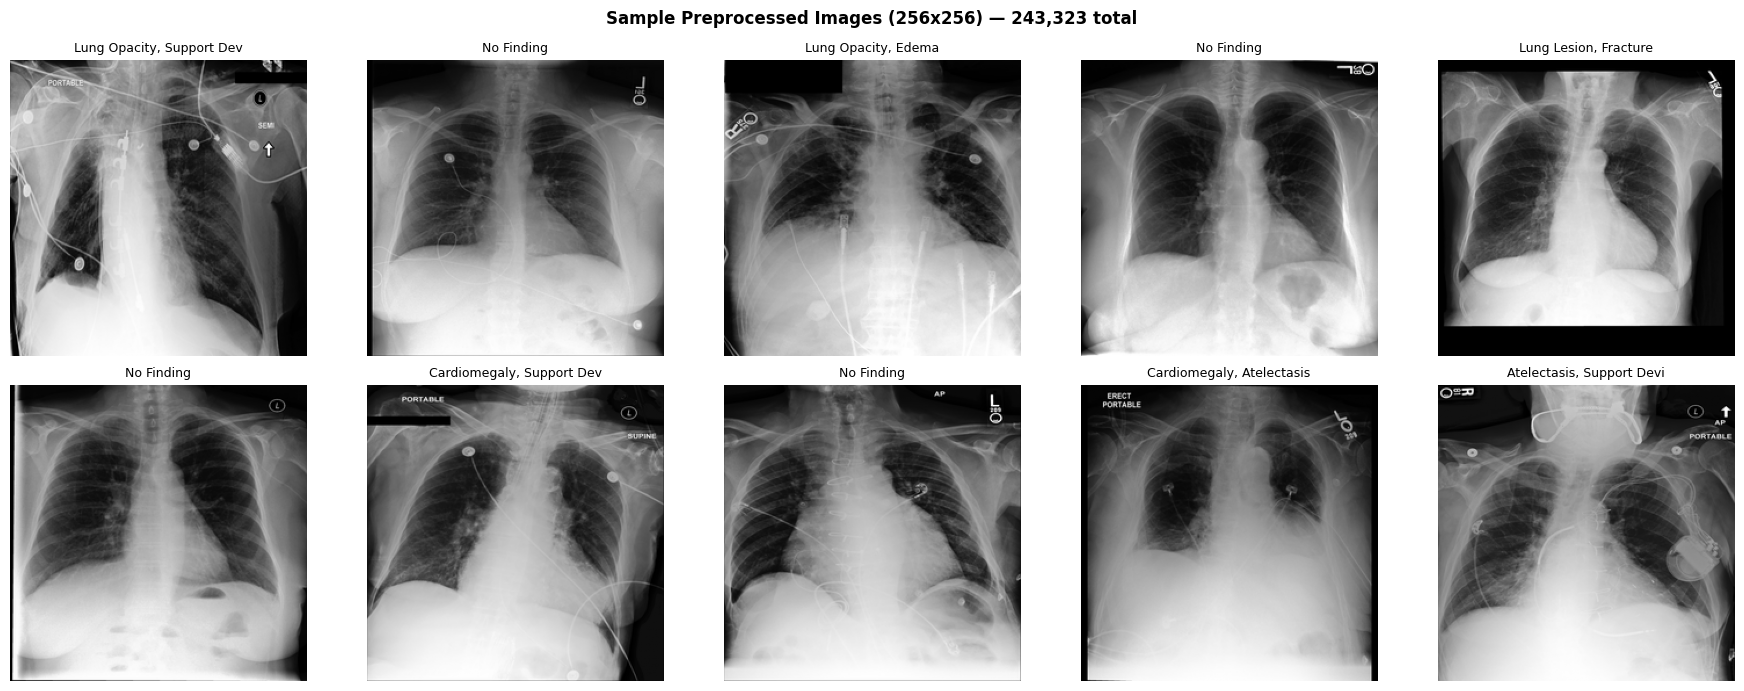

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

samples = manifest_df.sample(10, random_state=42)

for ax, (_, row) in zip(axes, samples.iterrows()):
    img_path = os.path.join(OUTPUT_IMAGES, row['image_filename'])
    if os.path.exists(img_path):
        img = Image.open(img_path)
        pos_labels = [c for c in CHEXPERT_LABELS if c in row and row[c] == 1]
        title = ', '.join(pos_labels[:2]) if pos_labels else 'No Finding'
        ax.imshow(img, cmap='gray')
        ax.set_title(title[:25], fontsize=9)
    ax.axis('off')

plt.suptitle(f'Sample Preprocessed Images (256x256) — {len(manifest_df):,} total',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_preview.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Quick image quality check — verify size and pixel range
check_samples = manifest_df.sample(50, random_state=0)
sizes = []
for _, row in check_samples.iterrows():
    p = os.path.join(OUTPUT_IMAGES, row['image_filename'])
    if os.path.exists(p):
        img = Image.open(p)
        sizes.append(img.size)

unique_sizes = set(sizes)
print(f'Checked 50 random images:')
print(f'  Unique sizes: {unique_sizes}')
print(f'  All 256x256: {unique_sizes == {(256, 256)}}')

Checked 50 random images:
  Unique sizes: {(256, 256)}
  All 256x256: True


## Step 10 — Save labels.csv (for training)

Clean CSV with just `image_filename` + 14 binary labels.

In [ ]:
label_cols = ['image_filename'] + [c for c in CHEXPERT_LABELS if c in manifest_df.columns]
labels_df = manifest_df[label_cols].copy()

labels_path = os.path.join(OUTPUT_DIR, 'labels.csv')
labels_df.to_csv(labels_path, index=False)

print(f'Labels saved: {labels_path}')
print(f'Shape: {labels_df.shape}')
print(f'\nFirst 5 rows:')
labels_df.head()

Labels saved: /content/drive/MyDrive/cloudBuc/preprocessed_256/labels.csv
Shape: (243323, 15)

First 5 rows:


,image_filename,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.png,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.png,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.png,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.png,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.png,1,0,0,0,0,0,0,0,0,0,0,0,0,0


## Step 11 — Sample 2000 Images per Class & Pack into TAR

---

## Done!

**Output structure:**
```
preprocessed_256/
├── images/           # 256×256 grayscale PNGs (~150K+ images)
├── manifest.csv      # Full metadata + labels
├── labels.csv        # image_filename + 14 binary labels (for training)
├── sample_preview.png
├── _progress.txt     # Resume tracker
└── _done_p1X.csv     # Per-folder checkpoints
```

**Next:** Upload `preprocessed_256/` to vast.ai and point your dataset loader at it.